# Visualization 1: U.S. PADD Map with Gas Prices & Refinery Locations

Creates a choropleth map of the U.S. colored by average gas price per PADD region,
with refinery locations plotted on top.

**Run this after `02_Data_Cleaning.ipynb` has completed.**

In [1]:
!conda install -y -c conda-forge geopandas --quiet

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: ...working... done

# All requested packages already installed.



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd
import json
import requests
from pathlib import Path
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

Path('outputs').mkdir(exist_ok=True)
print('✅ Imports ready')

✅ Imports ready


## 1. Load State Boundaries

Download a U.S. states shapefile from the Census Bureau.

In [3]:
# Download US states shapefile from Census Bureau
states_url = 'https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json'

cache_path = Path('data/raw/us-states.json')
if cache_path.exists():
    print('Loading cached states GeoJSON...')
    states = gpd.read_file(str(cache_path))
else:
    print('Downloading US states GeoJSON...')
    resp = requests.get(states_url)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache_path.write_text(resp.text)
    states = gpd.read_file(str(cache_path))

# Remove Alaska, Hawaii, Puerto Rico for cleaner continental map
exclude = ['Alaska', 'Hawaii', 'Puerto Rico']
states = states[~states['name'].isin(exclude)].copy()

print(f'✅ Loaded {len(states)} continental U.S. states')

Loading cached states GeoJSON...
✅ Loaded 49 continental U.S. states


## 2. Assign States to PADD Regions

In [22]:
# ============================================================
# REPLACE CELL 4 with this — ~125 refineries + oil fields
# ============================================================

refineries = pd.DataFrame([
    # === PADD 3 — Gulf Coast ===
    {'name': 'Motiva (Port Arthur, TX)', 'lat': 29.87, 'lon': -93.93, 'capacity': 630},
    {'name': 'ExxonMobil (Baytown, TX)', 'lat': 29.73, 'lon': -94.99, 'capacity': 584},
    {'name': 'Marathon (Galveston Bay, TX)', 'lat': 29.37, 'lon': -94.91, 'capacity': 593},
    {'name': 'Valero (Port Arthur, TX)', 'lat': 29.90, 'lon': -93.96, 'capacity': 395},
    {'name': 'Phillips 66 (Sweeny, TX)', 'lat': 29.08, 'lon': -95.73, 'capacity': 264},
    {'name': 'Valero (Corpus Christi W, TX)', 'lat': 27.83, 'lon': -97.46, 'capacity': 290},
    {'name': 'Valero (Corpus Christi E, TX)', 'lat': 27.80, 'lon': -97.40, 'capacity': 115},
    {'name': 'Valero (Texas City, TX)', 'lat': 29.39, 'lon': -94.93, 'capacity': 225},
    {'name': 'Marathon (Texas City, TX)', 'lat': 29.40, 'lon': -94.95, 'capacity': 104},
    {'name': 'Flint Hills (Corpus Christi, TX)', 'lat': 27.78, 'lon': -97.44, 'capacity': 300},
    {'name': 'Citgo (Corpus Christi, TX)', 'lat': 27.76, 'lon': -97.42, 'capacity': 167},
    {'name': 'TOTAL (Port Arthur, TX)', 'lat': 29.85, 'lon': -93.98, 'capacity': 225},
    {'name': 'Valero (Houston, TX)', 'lat': 29.72, 'lon': -95.22, 'capacity': 205},
    {'name': 'LyondellBasell (Houston, TX)', 'lat': 29.74, 'lon': -95.20, 'capacity': 268},
    {'name': 'Shell (Deer Park, TX)', 'lat': 29.67, 'lon': -95.12, 'capacity': 340},
    {'name': 'Petrobras (Pasadena, TX)', 'lat': 29.69, 'lon': -95.15, 'capacity': 110},
    {'name': 'Delek (Tyler, TX)', 'lat': 32.32, 'lon': -95.28, 'capacity': 75},
    {'name': 'Delek (Big Spring, TX)', 'lat': 32.25, 'lon': -101.46, 'capacity': 73},
    {'name': 'Valero (Three Rivers, TX)', 'lat': 28.46, 'lon': -98.18, 'capacity': 100},
    {'name': 'Valero (McKee, TX)', 'lat': 35.48, 'lon': -101.68, 'capacity': 195},
    {'name': 'Calumet (San Antonio, TX)', 'lat': 29.42, 'lon': -98.49, 'capacity': 18},
    {'name': 'AGE (Krotz Springs, LA)', 'lat': 30.54, 'lon': -91.75, 'capacity': 42},
    {'name': 'ExxonMobil (Baton Rouge, LA)', 'lat': 30.50, 'lon': -91.19, 'capacity': 523},
    {'name': 'Marathon (Garyville, LA)', 'lat': 30.06, 'lon': -90.62, 'capacity': 578},
    {'name': 'Phillips 66 (Lake Charles, LA)', 'lat': 30.24, 'lon': -93.28, 'capacity': 264},
    {'name': 'Valero (St. Charles, LA)', 'lat': 29.95, 'lon': -90.38, 'capacity': 250},
    {'name': 'Citgo (Lake Charles, LA)', 'lat': 30.19, 'lon': -93.22, 'capacity': 427},
    {'name': 'Calcasieu (Lake Charles, LA)', 'lat': 30.21, 'lon': -93.25, 'capacity': 135},
    {'name': 'Phillips 66 (Alliance, LA)', 'lat': 29.91, 'lon': -89.96, 'capacity': 255},
    {'name': 'PBF Energy (Chalmette, LA)', 'lat': 29.95, 'lon': -89.97, 'capacity': 189},
    {'name': 'Valero (Meraux, LA)', 'lat': 29.92, 'lon': -89.93, 'capacity': 135},
    {'name': 'Calumet (Shreveport, LA)', 'lat': 32.47, 'lon': -93.81, 'capacity': 60},
    {'name': 'Calumet (Cotton Valley, LA)', 'lat': 32.82, 'lon': -93.42, 'capacity': 12},
    {'name': 'Delek (El Dorado, AR)', 'lat': 33.21, 'lon': -92.66, 'capacity': 80},
    {'name': 'CDEP (El Dorado, AR)', 'lat': 33.23, 'lon': -92.68, 'capacity': 6},
    {'name': 'Valero (Memphis, TN)', 'lat': 35.07, 'lon': -90.05, 'capacity': 195},
    {'name': 'Chevron (Pascagoula, MS)', 'lat': 30.35, 'lon': -88.55, 'capacity': 330},
    {'name': 'Hunt (Tuscaloosa, AL)', 'lat': 33.18, 'lon': -87.54, 'capacity': 72},
    {'name': 'HF Sinclair (Artesia, NM)', 'lat': 32.84, 'lon': -104.40, 'capacity': 100},
    {'name': 'Western Ref (Gallup, NM)', 'lat': 35.52, 'lon': -108.74, 'capacity': 26},

    # === PADD 5 — West Coast ===
    {'name': 'Chevron (El Segundo, CA)', 'lat': 33.91, 'lon': -118.41, 'capacity': 290},
    {'name': 'Marathon (Carson, CA)', 'lat': 33.84, 'lon': -118.24, 'capacity': 363},
    {'name': 'Valero (Benicia, CA)', 'lat': 38.07, 'lon': -122.14, 'capacity': 145},
    {'name': 'Marathon (Martinez, CA)', 'lat': 38.02, 'lon': -122.10, 'capacity': 161},
    {'name': 'PBF Energy (Torrance, CA)', 'lat': 33.80, 'lon': -118.32, 'capacity': 155},
    {'name': 'Chevron (Richmond, CA)', 'lat': 37.93, 'lon': -122.38, 'capacity': 245},
    {'name': 'Phillips 66 (Rodeo, CA)', 'lat': 38.03, 'lon': -122.26, 'capacity': 120},
    {'name': 'Valero (Wilmington, CA)', 'lat': 33.78, 'lon': -118.27, 'capacity': 85},
    {'name': 'Kern Oil (Bakersfield, CA)', 'lat': 35.37, 'lon': -119.02, 'capacity': 26},
    {'name': 'San Joaquin (Bakersfield, CA)', 'lat': 35.35, 'lon': -119.05, 'capacity': 15},
    {'name': 'Phillips 66 (Santa Maria, CA)', 'lat': 34.88, 'lon': -120.40, 'capacity': 44},
    {'name': 'Phillips 66 (Ferndale, WA)', 'lat': 48.83, 'lon': -122.71, 'capacity': 105},
    {'name': 'Marathon (Anacortes, WA)', 'lat': 48.49, 'lon': -122.61, 'capacity': 119},
    {'name': 'Shell (Puget Sound, WA)', 'lat': 48.52, 'lon': -122.56, 'capacity': 149},
    {'name': 'Par Pacific (Tacoma, WA)', 'lat': 47.27, 'lon': -122.42, 'capacity': 42},
    {'name': 'Navajo (Artesia, NM)', 'lat': 32.82, 'lon': -104.42, 'capacity': 25},

    # === PADD 1 — East Coast ===
    {'name': 'PBF Energy (Delaware City, DE)', 'lat': 39.58, 'lon': -75.52, 'capacity': 190},
    {'name': 'Philadelphia Energy (PA)', 'lat': 39.92, 'lon': -75.14, 'capacity': 335},
    {'name': 'PBF Energy (Paulsboro, NJ)', 'lat': 39.84, 'lon': -75.25, 'capacity': 180},
    {'name': 'Phillips 66 (Linden, NJ)', 'lat': 40.63, 'lon': -74.24, 'capacity': 258},
    {'name': 'Ergon (Newell, WV)', 'lat': 39.40, 'lon': -80.85, 'capacity': 23},
    {'name': 'Calumet (Princeton, LA)', 'lat': 32.52, 'lon': -93.58, 'capacity': 10},
    {'name': 'Irving Oil (St. John, NB)', 'lat': 45.25, 'lon': -66.05, 'capacity': 320},
    {'name': 'United (Warren, PA)', 'lat': 41.84, 'lon': -79.14, 'capacity': 70},
    {'name': 'American Ref (Bradford, PA)', 'lat': 41.96, 'lon': -78.64, 'capacity': 11},
    {'name': 'Ergon (Vicksburg, MS)', 'lat': 32.35, 'lon': -90.88, 'capacity': 27},

    # === PADD 2 — Midwest ===
    {'name': 'BP (Whiting, IN)', 'lat': 41.68, 'lon': -87.49, 'capacity': 440},
    {'name': 'Marathon (Robinson, IL)', 'lat': 39.01, 'lon': -87.74, 'capacity': 245},
    {'name': 'Phillips 66 (Wood River, IL)', 'lat': 38.86, 'lon': -90.11, 'capacity': 314},
    {'name': 'Flint Hills (Pine Bend, MN)', 'lat': 44.78, 'lon': -93.18, 'capacity': 339},
    {'name': 'Marathon (Detroit, MI)', 'lat': 42.29, 'lon': -83.12, 'capacity': 140},
    {'name': 'CVR Energy (Coffeyville, KS)', 'lat': 37.03, 'lon': -95.62, 'capacity': 132},
    {'name': 'Cenovus (Toledo, OH)', 'lat': 41.65, 'lon': -83.58, 'capacity': 150},
    {'name': 'Cenovus (Lima, OH)', 'lat': 40.74, 'lon': -84.10, 'capacity': 186},
    {'name': 'Marathon (Canton, OH)', 'lat': 40.82, 'lon': -81.40, 'capacity': 93},
    {'name': 'Marathon (Catlettsburg, KY)', 'lat': 38.39, 'lon': -82.61, 'capacity': 281},
    {'name': 'Phillips 66 (Ponca City, OK)', 'lat': 36.72, 'lon': -97.09, 'capacity': 198},
    {'name': 'HF Sinclair (Tulsa, OK)', 'lat': 36.14, 'lon': -96.01, 'capacity': 125},
    {'name': 'CVR Energy (Wynnewood, OK)', 'lat': 34.64, 'lon': -97.17, 'capacity': 74},
    {'name': 'Valero (Ardmore, OK)', 'lat': 34.16, 'lon': -97.14, 'capacity': 90},
    {'name': 'HF Sinclair (El Dorado, KS)', 'lat': 37.82, 'lon': -96.86, 'capacity': 135},
    {'name': 'CHS (McPherson, KS)', 'lat': 38.37, 'lon': -97.66, 'capacity': 120},
    {'name': 'Calumet (Superior, WI)', 'lat': 46.68, 'lon': -92.10, 'capacity': 45},
    {'name': 'Marathon (St. Paul, MN)', 'lat': 44.92, 'lon': -93.02, 'capacity': 102},
    {'name': 'Flint Hills (Rosemount, MN)', 'lat': 44.73, 'lon': -93.12, 'capacity': 100},
    {'name': 'Phillips 66 (Borger, TX)', 'lat': 35.66, 'lon': -101.40, 'capacity': 146},
    {'name': 'Tesoro (Mandan, ND)', 'lat': 46.83, 'lon': -100.89, 'capacity': 71},
    {'name': 'Calumet (Indianapolis, IN)', 'lat': 39.79, 'lon': -86.08, 'capacity': 28},
    {'name': 'CountryMark (Mt Vernon, IN)', 'lat': 37.93, 'lon': -87.89, 'capacity': 29},
    {'name': 'Frontier (El Dorado, KS)', 'lat': 37.84, 'lon': -96.89, 'capacity': 45},
    {'name': 'NCRA (McPherson, KS)', 'lat': 38.39, 'lon': -97.64, 'capacity': 85},
    {'name': 'WRB (Borger, TX)', 'lat': 35.68, 'lon': -101.42, 'capacity': 56},
    {'name': 'Coffeyville Res (KS)', 'lat': 37.05, 'lon': -95.60, 'capacity': 115},
    {'name': 'Calumet (Karns City, PA)', 'lat': 40.97, 'lon': -79.72, 'capacity': 10},
    {'name': 'Somerset (Somerset, KY)', 'lat': 37.09, 'lon': -84.60, 'capacity': 7},
    {'name': 'Ergon (Vicksburg, MS)', 'lat': 32.33, 'lon': -90.90, 'capacity': 25},
    {'name': 'Placid (Port Allen, LA)', 'lat': 30.45, 'lon': -91.21, 'capacity': 56},
    {'name': 'Pelican (Lake Charles, LA)', 'lat': 30.17, 'lon': -93.20, 'capacity': 65},
    {'name': 'Calumet (Princeton, WI)', 'lat': 43.85, 'lon': -89.48, 'capacity': 8},
    {'name': 'Frontier (Cheyenne, WY)', 'lat': 41.15, 'lon': -104.80, 'capacity': 52},

    # === PADD 4 — Rocky Mountain ===
    {'name': 'Suncor (Commerce City, CO)', 'lat': 39.82, 'lon': -104.93, 'capacity': 98},
    {'name': 'HF Sinclair (Sinclair, WY)', 'lat': 41.78, 'lon': -107.12, 'capacity': 80},
    {'name': 'Phillips 66 (Billings, MT)', 'lat': 45.79, 'lon': -108.55, 'capacity': 62},
    {'name': 'Marathon (Salt Lake City, UT)', 'lat': 40.73, 'lon': -111.93, 'capacity': 61},
    {'name': 'ExxonMobil (Billings, MT)', 'lat': 45.77, 'lon': -108.52, 'capacity': 60},
    {'name': 'Calumet (Great Falls, MT)', 'lat': 47.50, 'lon': -111.30, 'capacity': 30},
    {'name': 'HF Sinclair (Casper, WY)', 'lat': 42.85, 'lon': -106.31, 'capacity': 27},
    {'name': 'HF Sinclair (Cheyenne, WY)', 'lat': 41.13, 'lon': -104.82, 'capacity': 52},
    {'name': 'Silver Eagle (Woods Cross, UT)', 'lat': 40.87, 'lon': -111.92, 'capacity': 29},
    {'name': 'Chevron (Salt Lake City, UT)', 'lat': 40.76, 'lon': -111.90, 'capacity': 51},
    {'name': 'Wyoming Ref (Newcastle, WY)', 'lat': 43.85, 'lon': -104.19, 'capacity': 14},
    {'name': 'Par Pacific (Newcastle, WY)', 'lat': 43.87, 'lon': -104.21, 'capacity': 18},
    {'name': 'Black Elk (Great Falls, MT)', 'lat': 47.52, 'lon': -111.32, 'capacity': 6},
    {'name': 'Calumet (Cut Bank, MT)', 'lat': 48.63, 'lon': -112.33, 'capacity': 9},
    {'name': 'Montana Ref (Great Falls, MT)', 'lat': 47.48, 'lon': -111.28, 'capacity': 10},
])

# Oil Production Regions
oil_fields = pd.DataFrame([
    {'name': 'Permian Basin', 'lat': 31.9, 'lon': -102.1, 'production': 6200},
    {'name': 'Eagle Ford', 'lat': 28.7, 'lon': -98.5, 'production': 1100},
    {'name': 'Bakken', 'lat': 47.9, 'lon': -103.5, 'production': 1200},
    {'name': 'Niobrara', 'lat': 40.5, 'lon': -104.5, 'production': 700},
    {'name': 'Anadarko', 'lat': 35.5, 'lon': -98.0, 'production': 400},
    {'name': 'Appalachian', 'lat': 39.5, 'lon': -80.0, 'production': 200},
    {'name': 'Williston', 'lat': 48.2, 'lon': -104.0, 'production': 350},
    {'name': 'Haynesville', 'lat': 32.3, 'lon': -93.8, 'production': 300},
    {'name': 'Utica/Marcellus', 'lat': 40.0, 'lon': -81.0, 'production': 500},
])

refineries_gdf = gpd.GeoDataFrame(
    refineries,
    geometry=gpd.points_from_xy(refineries['lon'], refineries['lat']),
    crs='EPSG:4326'
)

print(f'✅ {len(refineries)} refineries loaded')
print(f'✅ {len(oil_fields)} oil production regions loaded')
print(f'Total refining capacity: {refineries["capacity"].sum():,} kbd')

✅ 115 refineries loaded
✅ 9 oil production regions loaded
Total refining capacity: 17,182 kbd


## 3. Load Gas Prices by PADD

Get the most recent average gas price per PADD from our cleaned data.

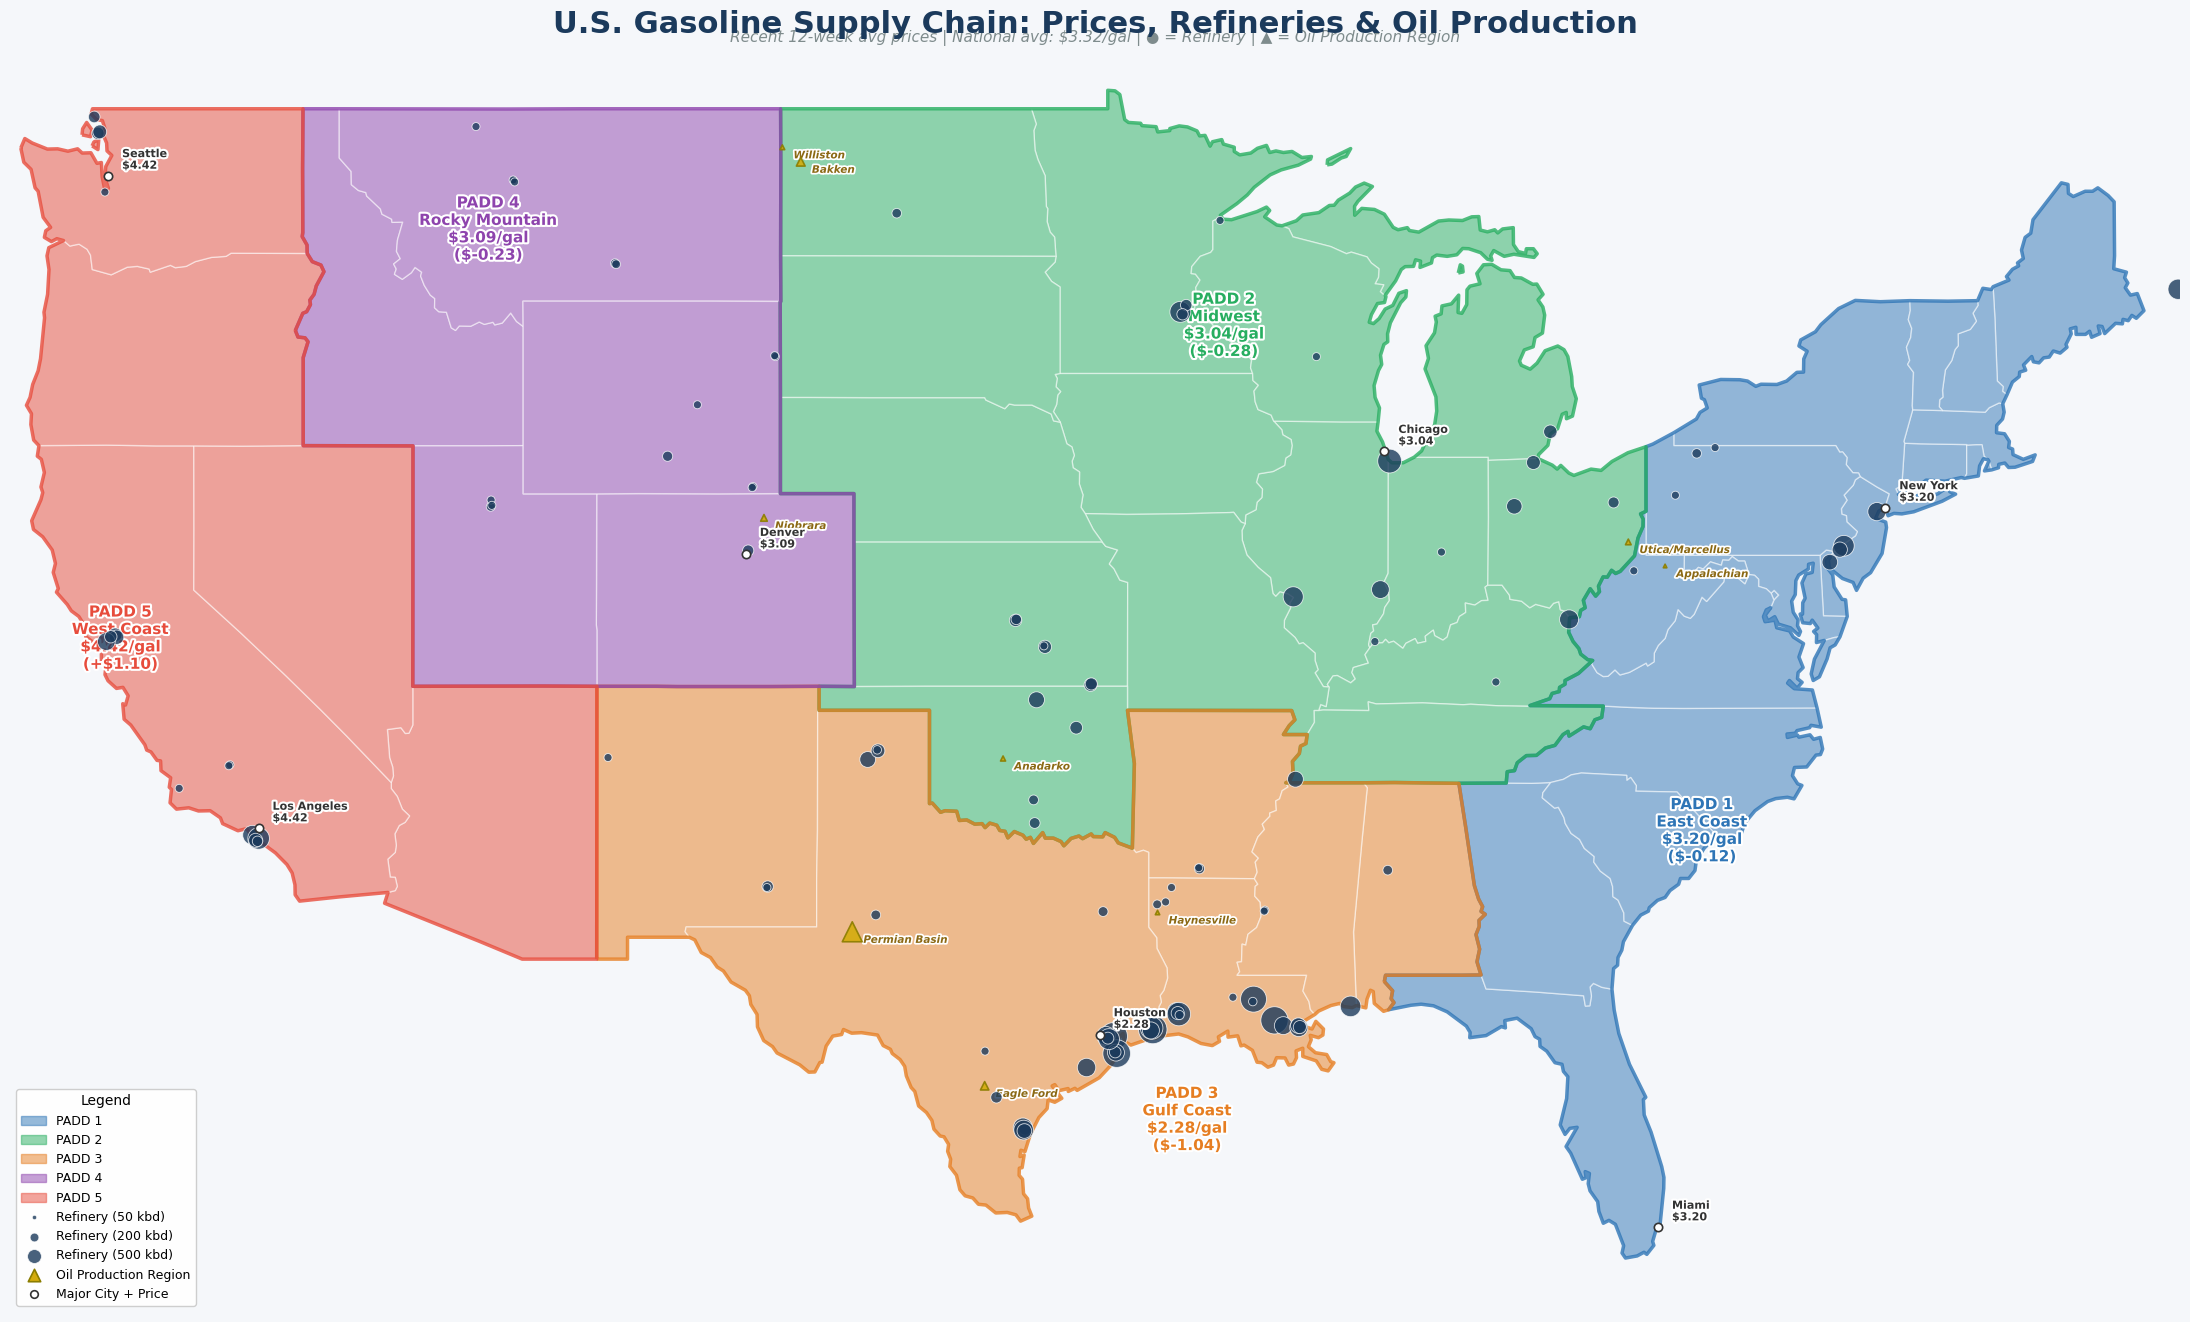


✅ Saved: outputs/map_padd_refineries_v2.png


In [25]:
# ============================================================
# REPLACE CELL 5 ("Create the Map") WITH THIS
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(22, 14))
fig.patch.set_facecolor('#F5F7FA')
ax.set_facecolor('#F5F7FA')

# ---- Color palette for PADDs ----
padd_colors = {
    'PADD 1\nEast Coast':     '#2E75B6',
    'PADD 2\nMidwest':        '#27AE60',
    'PADD 3\nGulf Coast':     '#E67E22',
    'PADD 4\nRocky Mountain': '#8E44AD',
    'PADD 5\nWest Coast':     '#E74C3C',
}

# ---- Plot states colored by PADD region ----
for padd, color in padd_colors.items():
    padd_states = states[states['padd'] == padd]
    padd_states.plot(ax=ax, color=color, alpha=0.5, edgecolor='white', linewidth=1.0)

# ---- Plot PADD borders (thicker) ----
for padd in padd_colors.keys():
    padd_states = states[states['padd'] == padd]
    dissolved = padd_states.dissolve()
    dissolved.boundary.plot(ax=ax, color=padd_colors[padd], linewidth=2.5, alpha=0.8)

# ---- Plot refineries (circles) ----
# Scale: minimum visible size of 15, max around 80
sizes = refineries['capacity'].clip(lower=50) / 1.5
ax.scatter(
    refineries['lon'], refineries['lat'],
    s=sizes,
    c='#1B3A5C',
    alpha=0.8,
    edgecolors='white',
    linewidths=0.6,
    zorder=5,
)

# ---- Plot oil production regions (triangles) ----
oil_sizes = oil_fields['production'] / 30
ax.scatter(
    oil_fields['lon'], oil_fields['lat'],
    s=oil_sizes,
    c='#D4AC0D',
    marker='^',
    alpha=0.9,
    edgecolors='#8B7D00',
    linewidths=1.2,
    zorder=6,
)
# Label oil fields
for _, row in oil_fields.iterrows():
    ax.annotate(
        row['name'],
        xy=(row['lon'], row['lat']),
        xytext=(8, -8),
        textcoords='offset points',
        fontsize=7.5,
        color='#8B6914',
        fontstyle='italic',
        fontweight='bold',
        path_effects=[pe.withStroke(linewidth=2.5, foreground='white')],
    )

# ---- Add city labels with regional prices ----
cities = [
    {'city': 'Los Angeles', 'lat': 34.05, 'lon': -118.24, 'padd': 'PADD 5\nWest Coast'},
    {'city': 'Houston', 'lat': 29.76, 'lon': -95.37, 'padd': 'PADD 3\nGulf Coast'},
    {'city': 'Chicago', 'lat': 41.88, 'lon': -87.63, 'padd': 'PADD 2\nMidwest'},
    {'city': 'New York', 'lat': 40.71, 'lon': -74.01, 'padd': 'PADD 1\nEast Coast'},
    {'city': 'Denver', 'lat': 39.74, 'lon': -104.99, 'padd': 'PADD 4\nRocky Mountain'},
    {'city': 'Miami', 'lat': 25.76, 'lon': -80.19, 'padd': 'PADD 1\nEast Coast'},
    {'city': 'Seattle', 'lat': 47.61, 'lon': -122.33, 'padd': 'PADD 5\nWest Coast'},
]

for c in cities:
    price = padd_avg_prices.get(c['padd'], np.nan)
    if not np.isnan(price):
        label = f"{c['city']}\n${price:.2f}"
    else:
        label = c['city']
    
    ax.plot(c['lon'], c['lat'], 'o', color='white', markersize=6, markeredgecolor='#333333', 
            markeredgewidth=1.2, zorder=7)
    ax.annotate(
        label,
        xy=(c['lon'], c['lat']),
        xytext=(10, 5),
        textcoords='offset points',
        fontsize=8,
        fontweight='bold',
        color='#333333',
        path_effects=[pe.withStroke(linewidth=3, foreground='white')],
        zorder=8,
    )

# ---- Add PADD labels with prices ----
label_positions = {
    'PADD 1\nEast Coast':     (-79.0, 34.0),
    'PADD 2\nMidwest':        (-92.0, 44.5),
    'PADD 3\nGulf Coast':     (-93.0, 28.0),
    'PADD 4\nRocky Mountain': (-112.0, 46.5),
    'PADD 5\nWest Coast':     (-122.0, 38.0),
}

for padd, (lx, ly) in label_positions.items():
    price = padd_avg_prices.get(padd, np.nan)
    premium = padd_premium.get(padd, 0)
    color = padd_colors[padd]
    
    if not np.isnan(price):
        sign = '+' if premium > 0 else ''
        label_text = f'{padd}\n${price:.2f}/gal\n({sign}${premium:.2f})'
    else:
        label_text = padd
    
    ax.annotate(
        label_text,
        xy=(lx, ly),
        fontsize=11,
        fontweight='bold',
        color=color,
        ha='center',
        va='center',
        path_effects=[pe.withStroke(linewidth=3, foreground='white')],
    )

# ---- Title ----
ax.set_title(
    'U.S. Gasoline Supply Chain: Prices, Refineries & Oil Production',
    fontsize=22, fontweight='bold', color='#1B3A5C', pad=20
)
ax.text(
    0.5, 1.015,
    f'Recent 12-week avg prices | National avg: ${national_avg:.2f}/gal | ● = Refinery | ▲ = Oil Production Region',
    transform=ax.transAxes, ha='center', fontsize=11, color='#7F8C8D', style='italic'
)

# ---- Legend ----
legend_elements = []
for padd, color in padd_colors.items():
    short_name = padd.split('\n')[0]
    legend_elements.append(mpatches.Patch(facecolor=color, alpha=0.5, edgecolor=color, label=short_name))

# Refinery sizes
for cap, label in [(50, '50 kbd'), (200, '200 kbd'), (500, '500 kbd')]:
    legend_elements.append(
        plt.scatter([], [], s=max(cap, 20)/5, c='#1B3A5C', alpha=0.8, edgecolors='white', linewidths=0.6, label=f'Refinery ({label})')
    )

# Oil field
legend_elements.append(
    plt.scatter([], [], s=80, c='#D4AC0D', marker='^', edgecolors='#8B7D00', linewidths=1.2, label='Oil Production Region')
)

# City marker
legend_elements.append(
    plt.scatter([], [], s=30, c='white', edgecolors='#333333', linewidths=1.2, label='Major City + Price')
)

ax.legend(
    handles=legend_elements,
    loc='lower left',
    fontsize=9,
    framealpha=0.95,
    edgecolor='#CCCCCC',
    title='Legend',
    title_fontsize=10,
    fancybox=True,
)

# ---- Clean up axes ----
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('outputs/map_padd_refineries_v2.png', dpi=200, bbox_inches='tight', facecolor='#F5F7FA')
plt.show()
print('\n✅ Saved: outputs/map_padd_refineries_v2.png')

## 6. Bonus: Price Premium Map (Diverging Colors)

A second version where color intensity shows how much MORE or LESS each region pays vs the national average. Red = pays more, blue = pays less.

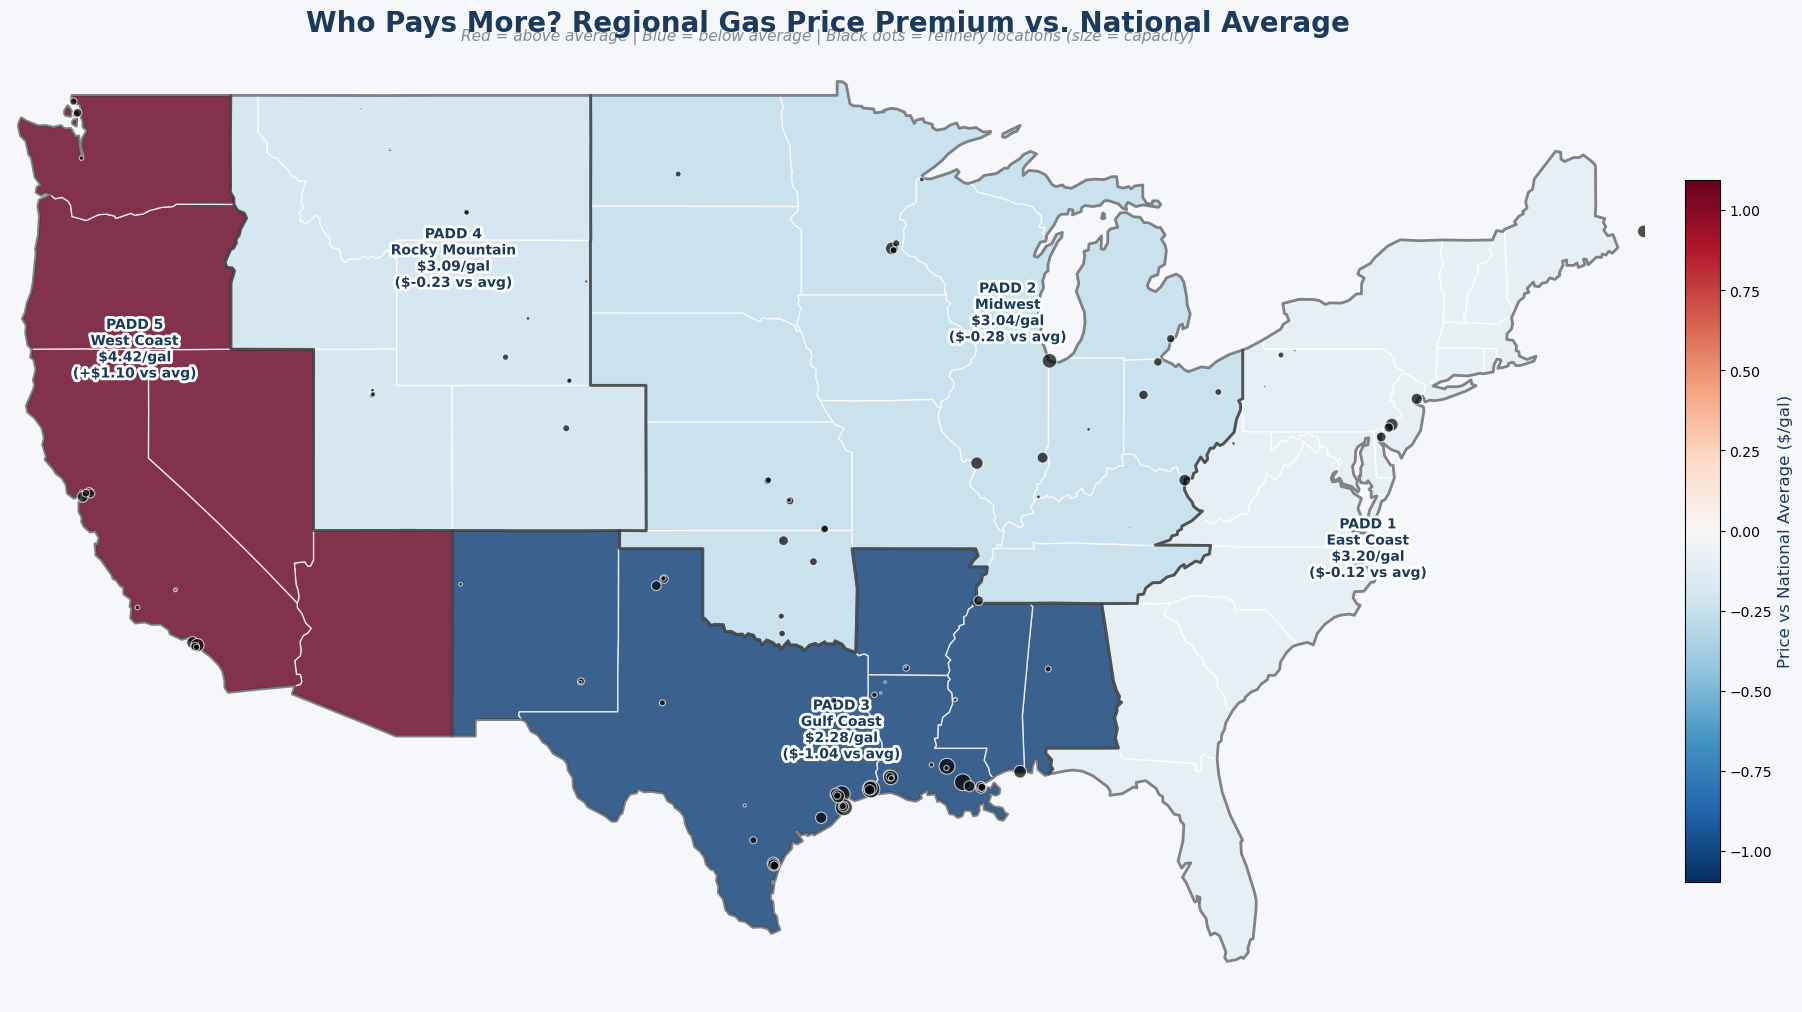


✅ Saved: outputs/map_price_premium.png


In [29]:
fig, ax = plt.subplots(1, 1, figsize=(20, 12))
fig.patch.set_facecolor('#F5F7FA')
ax.set_facecolor('#F5F7FA')

# ---- Plot states with diverging colormap based on price premium ----
# Red = above national average, Blue = below
from matplotlib.colors import TwoSlopeNorm

vmax = max(abs(states['premium'].min()), abs(states['premium'].max()))
if vmax == 0 or np.isnan(vmax):
    vmax = 0.5  # fallback
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

states.plot(
    column='premium',
    ax=ax,
    cmap='RdBu_r',  # Red = expensive, Blue = cheap
    norm=norm,
    edgecolor='white',
    linewidth=1.0,
    legend=False,
    alpha=0.8,
)

# ---- Plot PADD borders ----
for padd in padd_colors.keys():
    padd_states = states[states['padd'] == padd]
    dissolved = padd_states.dissolve()
    dissolved.boundary.plot(ax=ax, color='#333333', linewidth=2, alpha=0.6)

# ---- Plot refineries ----
sizes = refineries['capacity'] / 4
ax.scatter(
    refineries['lon'], refineries['lat'],
    s=sizes,
    c='black',
    alpha=0.7,
    edgecolors='white',
    linewidths=0.8,
    zorder=5,
)

# ---- Add price labels ----
for padd, (lx, ly) in label_positions.items():
    price = padd_avg_prices.get(padd, np.nan)
    premium = padd_premium.get(padd, 0)
    
    if not np.isnan(price):
        sign = '+' if premium > 0 else ''
        label_text = f'{padd}\n${price:.2f}/gal\n({sign}${premium:.2f} vs avg)'
    else:
        label_text = padd
    
    ax.annotate(
        label_text,
        xy=(lx, ly),
        fontsize=10,
        fontweight='bold',
        color='#1B3A5C',
        ha='center',
        va='center',
        path_effects=[pe.withStroke(linewidth=4, foreground='white')],
    )

# ---- Colorbar ----
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, aspect=20, pad=0.02)
cbar.set_label('Price vs National Average ($/gal)', fontsize=12, color='#1B3A5C')
cbar.ax.tick_params(labelsize=10)

# ---- Title ----
ax.set_title(
    'Who Pays More? Regional Gas Price Premium vs. National Average',
    fontsize=20, fontweight='bold', color='#1B3A5C', pad=20
)
ax.text(
    0.5, 1.02,
    f'Red = above average | Blue = below average | Black dots = refinery locations (size = capacity)',
    transform=ax.transAxes, ha='center', fontsize=11, color='#7F8C8D', style='italic'
)

# ---- Clean up ----
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('outputs/map_price_premium.png', dpi=200, bbox_inches='tight', facecolor='#F5F7FA')
plt.show()
print('\n✅ Saved: outputs/map_price_premium.png')

In [21]:
print('📁 Map files saved:')
for f in sorted(Path('outputs').glob('map_*')):
    size_kb = f.stat().st_size / 1024
    print(f'   {f.name:<35} {size_kb:.0f} KB')
print('\n✅ Done! Use these for your poster and presentation.')

📁 Map files saved:
   map_padd_refineries.png             732 KB
   map_padd_refineries_v2.png          951 KB
   map_price_premium.png               676 KB

✅ Done! Use these for your poster and presentation.
